# Validación de datos con Pandera y tracking de experimentos con MLflow
**Alumno: Edgar Cano Orozco**

En este notebook se agregan dos componentes clave al pipeline de clasificación de churn de clientes de tarjeta de crédito:

1. **Pandera**, para validar la estructura y calidad del dataset antes del entrenamiento.
2. **MLflow**, para registrar de forma reproducible los experimentos de modelado.

La motivación de esta etapa es pasar de un notebook exploratorio a un flujo más cercano a producción. 
Un pipeline de machine learning puede entrenar incluso con datos sucios o inconsistentes, pero eso no garantiza resultados confiables. 
Por ello, primero se valida el dataset y después se entrena. Además, cada experimento se registra con sus parámetros, métricas y artefactos para facilitar la comparación entre modelos.

En términos del proyecto final, esta etapa cubre dos requisitos obligatorios:
- definir un `DataFrameSchema` con Pandera antes de entrenar;
- registrar en MLflow los experimentos con hiperparámetros, métricas y el modelo serializado.

## 1. Imports

In [80]:
import json
import tempfile
import time
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd
from pandera import Check, Column, DataFrameSchema
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    auc,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

## 2. Carga y preparación inicial de datos

En esta sección se carga el dataset y se realiza una limpieza mínima para dejarlo listo para validación. 
No se hace todavía el preprocesamiento del pipeline; primero se revisa y valida la calidad estructural de los datos.

En notebooks previos se construyó una versión intermedia del dataset, eliminando columnas no útiles para modelado y agregando variables derivadas de feature engineering.
En este notebook se parte de esa versión intermedia para validar la calidad de los datos que efectivamente entrarán al pipeline de entrenamiento.

In [3]:
DATA_PATH = Path("../data/interim/churn_base.parquet")
df = pd.read_parquet(DATA_PATH)

df.shape

(10127, 23)

In [6]:
df.dtypes

Attrition_Flag                  object
Customer_Age                     int64
Gender                          object
Dependent_count                  int64
Education_Level                 object
Marital_Status                  object
Income_Category                 object
Card_Category                   object
Months_on_book                   int64
Total_Relationship_Count         int64
Months_Inactive_12_mon           int64
Contacts_Count_12_mon            int64
Credit_Limit                   float64
Total_Revolving_Bal              int64
Avg_Open_To_Buy                float64
Total_Amt_Chng_Q4_Q1           float64
Total_Trans_Amt                  int64
Total_Trans_Ct                   int64
Total_Ct_Chng_Q4_Q1            float64
Avg_Utilization_Ratio          float64
Avg_Trans_Amt                  float64
Products_Per_Month             float64
Contacts_Per_Inactive_Month    float64
dtype: object

## 3. Validación de datos con Pandera

En notebooks previos se construyó una versión intermedia del dataset (`churn_base.parquet`), eliminando columnas no útiles para modelado y agregando variables derivadas de feature engineering.

En esta etapa se valida esa versión intermedia antes del entrenamiento. El objetivo es asegurar que:
- las columnas tengan el tipo esperado;
- los valores numéricos se encuentren en rangos razonables;
- las categorías sean válidas;
- las variables derivadas sean consistentes con las variables base;
- no existan duplicados completos en el dataset.

De esta forma, el pipeline falla temprano si detecta datos corruptos o inconsistentes.

In [15]:
# helpers
def check_credit_limit_consistency(df: pd.DataFrame) -> bool:
    return np.isclose(
        df["Credit_Limit"],
        df["Total_Revolving_Bal"] + df["Avg_Open_To_Buy"],
        rtol=1e-3,
        atol=1.0,
    ).all()


def check_avg_trans_amt(df: pd.DataFrame) -> bool:
    return np.isclose(
        df["Avg_Trans_Amt"],
        df["Total_Trans_Amt"] / df["Total_Trans_Ct"],
        rtol=1e-3,
        atol=1e-2,
    ).all()


def check_no_duplicate_rows(df: pd.DataFrame) -> bool:
    return df.duplicated().sum() == 0

In [16]:
churn_schema = DataFrameSchema(
    {
        "Attrition_Flag": Column(
            str,
            nullable=False,
            checks=Check.isin(["Existing Customer", "Attrited Customer"]),
        ),
        "Customer_Age": Column(
            int,
            nullable=False,
            checks=Check.in_range(18, 100),
        ),
        "Gender": Column(
            str,
            nullable=False,
            checks=Check.isin(["M", "F"]),
        ),
        "Dependent_count": Column(
            int,
            nullable=False,
            checks=Check.in_range(0, 10),
        ),
        "Education_Level": Column(
            str,
            nullable=False,
        ),
        "Marital_Status": Column(
            str,
            nullable=False,
        ),
        "Income_Category": Column(
            str,
            nullable=False,
        ),
        "Card_Category": Column(
            str,
            nullable=False,
        ),
        "Months_on_book": Column(
            int,
            nullable=False,
            checks=Check.greater_than(0),
        ),
        "Total_Relationship_Count": Column(
            int,
            nullable=False,
            checks=Check.in_range(1, 20),
        ),
        "Months_Inactive_12_mon": Column(
            int,
            nullable=False,
            checks=Check.in_range(0, 12),
        ),
        "Contacts_Count_12_mon": Column(
            int,
            nullable=False,
            checks=Check.in_range(0, 20),
        ),
        "Credit_Limit": Column(
            float,
            nullable=False,
            checks=Check.greater_than(0),
        ),
        "Total_Revolving_Bal": Column(
            float,
            nullable=False,
            checks=Check.greater_than_or_equal_to(0),
        ),
        "Avg_Open_To_Buy": Column(
            float,
            nullable=False,
            checks=Check.greater_than_or_equal_to(0),
        ),
        "Total_Amt_Chng_Q4_Q1": Column(
            float,
            nullable=False,
            checks=Check.greater_than_or_equal_to(0),
        ),
        "Total_Trans_Amt": Column(
            float,
            nullable=False,
            checks=Check.greater_than_or_equal_to(0),
        ),
        "Total_Trans_Ct": Column(
            int,
            nullable=False,
            checks=Check.greater_than(0),
        ),
        "Total_Ct_Chng_Q4_Q1": Column(
            float,
            nullable=False,
            checks=Check.greater_than_or_equal_to(0),
        ),
        "Avg_Utilization_Ratio": Column(
            float,
            nullable=False,
            checks=Check.in_range(0, 1),
        ),
        "Avg_Trans_Amt": Column(
            float,
            nullable=False,
            checks=Check.greater_than_or_equal_to(0),
        ),
        "Products_Per_Month": Column(
            float,
            nullable=False,
            checks=Check.greater_than(0),
        ),
        "Contacts_Per_Inactive_Month": Column(
            float,
            nullable=False,
            checks=Check.greater_than_or_equal_to(0),
        ),
    },
    checks=[
        Check(
            check_no_duplicate_rows,
            error="Se encontraron filas duplicadas en el dataset.",
        ),
        Check(
            check_credit_limit_consistency,
            error="Inconsistencia: Credit_Limit no coincide con "
            "Total_Revolving_Bal + Avg_Open_To_Buy.",
        ),
        Check(
            check_avg_trans_amt,
            error="Inconsistencia: Avg_Trans_Amt no coincide con "
            "Total_Trans_Amt / Total_Trans_Ct.",
        ),
    ],
    strict=True,
    coerce=True,
)

In [17]:
df_validated = churn_schema.validate(df, lazy=True)
df_validated.shape

(10127, 23)

In [18]:
print("Validación exitosa.")
print(f"Filas: {df_validated.shape[0]:,}")
print(f"Columnas: {df_validated.shape[1]}")

Validación exitosa.
Filas: 10,127
Columnas: 23


In [19]:
df_model = df_validated.copy()

df_model["Attrition_Flag"] = df_model["Attrition_Flag"].map(
    {
        "Existing Customer": 0,
        "Attrited Customer": 1,
    }
)

df_model["Attrition_Flag"].value_counts()

Attrition_Flag
0    8500
1    1627
Name: count, dtype: int64

### Justificación del schema

El schema se definió sobre la versión intermedia del dataset (`churn_base.parquet`), que ya había pasado por una etapa previa de limpieza y feature engineering.

Las validaciones cubren tres niveles:

1. **Validación por columna**  
   Se revisan tipos, ausencia de nulos y rangos razonables para variables numéricas.

2. **Validación cross-column**  
   Se comprueba consistencia entre variables relacionadas:
   - `Credit_Limit ≈ Total_Revolving_Bal + Avg_Open_To_Buy`
   - `Avg_Trans_Amt ≈ Total_Trans_Amt / Total_Trans_Ct`

3. **Validación a nivel DataFrame**  
   Se verifica que no existan filas completamente duplicadas.

Este enfoque permite detectar errores estructurales y lógicos antes de entrenar el modelo.

 ## 4. Serialización eficiente con Parquet

Una vez validado el dataset con Pandera, se guarda una nueva versión en formato Parquet. 
El objetivo es dejar un artefacto listo para experimentación y modelado, preservando tipos de datos y mejorando la eficiencia de almacenamiento y lectura.

Además, se compara Parquet contra CSV en dos dimensiones:
- tamaño en disco;
- tiempo de lectura.

Esto permite justificar el uso de Parquet como formato preferido en etapas intermedias del pipeline.

In [20]:
processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

csv_path = processed_dir / "churn_validated.csv"
parquet_path = processed_dir / "churn_validated.parquet"

In [21]:
# Guardar CSV
start_csv_write = time.perf_counter()
df_validated.to_csv(csv_path, index=False)
csv_write_time = time.perf_counter() - start_csv_write

# Guardar Parquet
start_parquet_write = time.perf_counter()
df_validated.to_parquet(
    parquet_path, index=False, engine="pyarrow", compression="snappy"
)
parquet_write_time = time.perf_counter() - start_parquet_write

In [22]:
csv_size_mb = csv_path.stat().st_size / (1024**2)
parquet_size_mb = parquet_path.stat().st_size / (1024**2)

print(f"Tamaño CSV: {csv_size_mb:.4f} MB")
print(f"Tamaño Parquet: {parquet_size_mb:.4f} MB")

Tamaño CSV: 1.5382 MB
Tamaño Parquet: 0.3457 MB


In [23]:
start_csv_read = time.perf_counter()
df_csv = pd.read_csv(csv_path)
csv_read_time = time.perf_counter() - start_csv_read

start_parquet_read = time.perf_counter()
df_parquet = pd.read_parquet(parquet_path)
parquet_read_time = time.perf_counter() - start_parquet_read

print(f"Lectura CSV: {csv_read_time:.6f} s")
print(f"Lectura Parquet: {parquet_read_time:.6f} s")

Lectura CSV: 0.025002 s
Lectura Parquet: 0.006545 s


In [24]:
selected_cols = ["Attrition_Flag", "Customer_Age", "Credit_Limit"]

start_partial_parquet = time.perf_counter()
df_partial = pd.read_parquet(parquet_path, columns=selected_cols)
partial_parquet_time = time.perf_counter() - start_partial_parquet

print(f"Lectura parcial Parquet ({selected_cols}): {partial_parquet_time:.6f} s")
df_partial.head()

Lectura parcial Parquet (['Attrition_Flag', 'Customer_Age', 'Credit_Limit']): 0.003359 s


,Attrition_Flag,Customer_Age,Credit_Limit
0,Existing Customer,45,12691.0
1,Existing Customer,49,8256.0
2,Existing Customer,51,3418.0
3,Existing Customer,40,3313.0
4,Existing Customer,40,4716.0


In [25]:
comparison = pd.DataFrame(
    {
        "metric": [
            "write_time_seconds",
            "read_time_seconds",
            "size_mb",
        ],
        "csv": [
            csv_write_time,
            csv_read_time,
            csv_size_mb,
        ],
        "parquet": [
            parquet_write_time,
            parquet_read_time,
            parquet_size_mb,
        ],
    }
)

comparison["improvement_ratio_csv_vs_parquet"] = (
    comparison["csv"] / comparison["parquet"]
)
comparison

,metric,csv,parquet,improvement_ratio_csv_vs_parquet
0,write_time_seconds,0.071203,0.009727,7.320390
1,read_time_seconds,0.025002,0.006545,3.820198
2,size_mb,1.538156,0.345683,4.449612


### Interpretación de resultados

La comparación muestra que Parquet es más conveniente que CSV para esta etapa del pipeline por tres razones:

1. **Preserva tipos de datos**  
   Esto reduce ambigüedades y mejora la reproducibilidad del flujo.

2. **Reduce tamaño en disco**  
   Gracias a la compresión nativa, el archivo Parquet suele ocupar menos espacio que el CSV.

3. **Mejora eficiencia de lectura**  
   La lectura completa suele ser más rápida y, además, Parquet permite leer solo las columnas necesarias, lo que resulta especialmente útil en pipelines de machine learning.

Por estas razones, la versión validada del dataset que se utilizará en las etapas posteriores será `churn_validated.parquet`.

## 5. Reutilización del pipeline base

En el notebook anterior se construyó el pipeline clásico de scikit-learn con preprocesamiento integrado. 
En esta sección se retoma esa estructura para reutilizarla en la fase de experimentación con MLflow.

El objetivo es mantener:
- separación clara entre variables predictoras y objetivo;
- preprocesamiento reproducible mediante `ColumnTransformer`;
- flexibilidad para comparar varios modelos sin reescribir la lógica de preparación de datos.

In [26]:
df_model = pd.read_parquet(parquet_path).copy()
df_model.shape

(10127, 23)

In [28]:
df_model["Attrition_Flag"] = df_model["Attrition_Flag"].map(
    {
        "Existing Customer": 0,
        "Attrited Customer": 1,
    }
)

df_model["Attrition_Flag"].value_counts(normalize=True)

Attrition_Flag
0    0.83934
1    0.16066
Name: proportion, dtype: float64

In [29]:
TARGET = "Attrition_Flag"

X = df_model.drop(columns=TARGET)
y = df_model[TARGET]

X.shape, y.shape

((10127, 22), (10127,))

In [30]:
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_features = X.select_dtypes(include=["number"]).columns.tolist()

print("Categóricas:", categorical_features)
print("Numéricas:", numeric_features)

Categóricas: ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']
Numéricas: ['Customer_Age', 'Dependent_count', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio', 'Avg_Trans_Amt', 'Products_Per_Month', 'Contacts_Per_Inactive_Month']


In [32]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

In [33]:
def make_pipeline(model):
    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", model),
        ]
    )

In [62]:
def train_and_evaluate(model, x_train, x_test, y_train, y_test):
    pipe = make_pipeline(model)
    pipe.fit(x_train, y_train)

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
    }

    return pipe, metrics

In [34]:
models = {
    "logistic_regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42,
    ),
    "random_forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced",
    ),
    "gradient_boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42,
    ),
}

In [35]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

baseline_results = []

for model_name, model in models.items():
    pipe = make_pipeline(model)

    scores = cross_validate(
        pipe,
        X,
        y,
        cv=cv,
        scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
        n_jobs=-1,
    )

    baseline_results.append(
        {
            "model": model_name,
            "accuracy_mean": scores["test_accuracy"].mean(),
            "precision_mean": scores["test_precision"].mean(),
            "recall_mean": scores["test_recall"].mean(),
            "f1_mean": scores["test_f1"].mean(),
            "roc_auc_mean": scores["test_roc_auc"].mean(),
        }
    )

baseline_results_df = pd.DataFrame(baseline_results).sort_values(
    "f1_mean", ascending=False
)
baseline_results_df

,model,accuracy_mean,precision_mean,recall_mean,f1_mean,roc_auc_mean
2,gradient_boosting,0.964648,0.929497,0.843860,0.884573,0.989740
1,random_forest,0.955564,0.934592,0.778105,0.849064,0.989568
0,logistic_regression,0.861461,0.544279,0.859840,0.666184,0.934784


En esta sección no se busca todavía registrar experimentos, sino verificar que la infraestructura base del pipeline sigue funcionando correctamente después de la etapa de validación con Pandera.

El uso de una función `make_pipeline()` permite comparar distintos modelos manteniendo constante el preprocesamiento. 
Esto facilita la experimentación y evita duplicar código, además de dejar la base lista para integrarse con MLflow en la siguiente sección.

## 6. MLFlow

In [49]:
mlruns_dir = Path("../mlruns_clean")

mlflow.set_tracking_uri(f"file:{mlruns_dir.resolve()}")
mlflow.set_experiment("credit-card-churn-scoring")

/opt/anaconda3/envs/IA_LLM_MI/lib/python3.11/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/04/22 15:20:29 INFO mlflow.tracking.fluent: Experiment with name 'credit-card-churn-scoring' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:///Users/edgarcanoorozco/Desktop/IA_LLM/Modulo_I/Proyecto_Final/credit-card-churn-scoring/mlruns_clean/975659266232956717', creation_time=1776892829230, experiment_id='975659266232956717', last_update_time=1776892829230, lifecycle_stage='active', name='credit-card-churn-scoring', tags={}, trace_location=None, workspace='default'>

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

X_train.shape, X_test.shape

((8101, 22), (2026, 22))

In [50]:
def run_experiment(model_name: str, model, x_train, x_test, y_train, y_test):
    pipe = make_pipeline(model)

    with mlflow.start_run(run_name=model_name):
        # 1. Registrar parámetros
        params = {
            "model_name": model_name,
            "train_rows": X_train.shape[0],
            "test_rows": X_test.shape[0],
            "n_features_raw": X_train.shape[1],
        }

        # parámetros específicos del modelo
        if hasattr(model, "get_params"):
            model_params = model.get_params()
            for key, value in model_params.items():
                params[f"model__{key}"] = value

        mlflow.log_params(params)

        # 2. Tags
        mlflow.set_tag("author", "Edgar Cano")
        mlflow.set_tag("dataset_version", "churn_validated.parquet")
        mlflow.set_tag("purpose", "baseline")

        # 3. Entrenamiento
        pipe.fit(X_train, y_train)

        # 4. Predicciones
        y_pred = pipe.predict(X_test)
        y_proba = pipe.predict_proba(X_test)[:, 1]

        # 5. Métricas
        metrics = {
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred),
            "recall": recall_score(y_test, y_pred),
            "f1": f1_score(y_test, y_pred),
            "roc_auc": roc_auc_score(y_test, y_proba),
        }

        mlflow.log_metrics(metrics)

        # 6. Guardar el pipeline completo como modelo
        mlflow.sklearn.log_model(pipe, name="model")

        return metrics

In [51]:
experiment_results = []

for model_name, model in models.items():
    metrics = run_experiment(
        model_name=model_name,
        model=model,
        X_train=X_train,
        X_test=X_test,
        y_train=y_train,
        y_test=y_test,
    )

    row = {"model": model_name}
    row.update(metrics)
    experiment_results.append(row)

results_df = pd.DataFrame(experiment_results).sort_values("f1", ascending=False)
results_df

2026/04/22 15:22:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/22 15:22:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/22 15:22:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mec

,model,accuracy,precision,recall,f1,roc_auc
2,gradient_boosting,0.962981,0.949640,0.812308,0.875622,0.988354
1,random_forest,0.952616,0.932075,0.760000,0.837288,0.986838
0,logistic_regression,0.871175,0.566946,0.833846,0.674969,0.934695


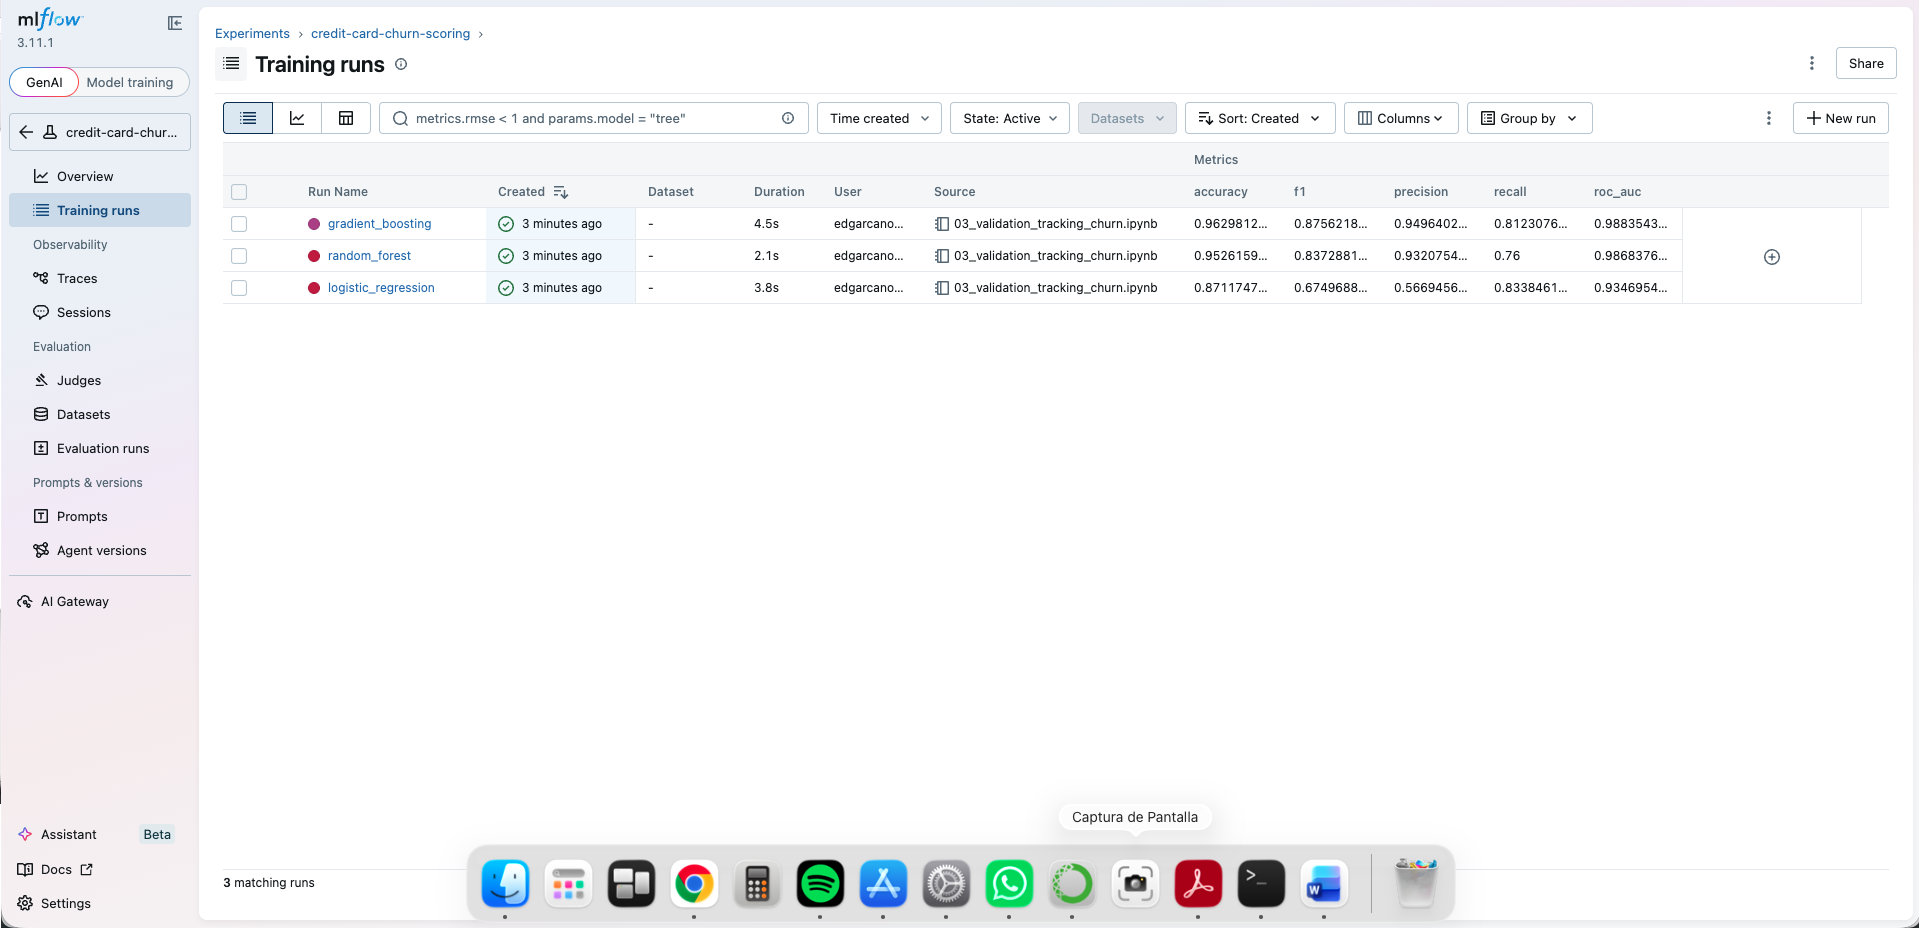

### Selección del modelo base ganador

A partir de las corridas iniciales registradas en MLflow, se compararon tres modelos base de clasificación: **Logistic Regression**, **Random Forest** y **Gradient Boosting**.

El modelo con mejor desempeño fue **Gradient Boosting**, al obtener los valores más altos en las métricas principales de evaluación, especialmente en **F1-score** y **ROC-AUC**. Esto sugiere que, dentro de las alternativas probadas, fue el modelo que logró el mejor balance entre capacidad predictiva y discriminación de clases.

Con base en este resultado, la siguiente etapa consistirá en realizar un proceso de **ajuste de hiperparámetros** sobre esta familia de modelos. Para ello, se utilizará la estructura de **parent run + child runs** en MLflow:

- el **parent run** representará el experimento general de tuning para Gradient Boosting;
- cada **child run** corresponderá a una configuración específica de hiperparámetros.

Este enfoque permite organizar de forma más clara el proceso de búsqueda, mantener agrupadas las variantes del mismo modelo y facilitar la comparación posterior entre configuraciones.

## 7. Tuning de hiperparámetros con parent run + child runs

Después de comparar los modelos base, se identificó que **Gradient Boosting** fue el modelo con mejor desempeño general.  
Por ello, la siguiente etapa consiste en explorar distintas configuraciones de hiperparámetros dentro de esta misma familia de modelos.

Para organizar este proceso se utilizará la estructura de **parent run + child runs** en MLflow:

- el **parent run** agrupa el experimento general de tuning;
- cada **child run** representa una combinación específica de hiperparámetros.

Este enfoque permite mantener ordenado el proceso de búsqueda y facilita la comparación posterior entre variantes del mismo modelo.

In [60]:
gb_configs = [
    {"n_estimators": 100, "learning_rate": 0.03, "max_depth": 2},
    {"n_estimators": 100, "learning_rate": 0.05, "max_depth": 3},
    {"n_estimators": 200, "learning_rate": 0.05, "max_depth": 3},
    {"n_estimators": 300, "learning_rate": 0.05, "max_depth": 3},
    {"n_estimators": 200, "learning_rate": 0.10, "max_depth": 2},
    {"n_estimators": 300, "learning_rate": 0.10, "max_depth": 3},
]

gb_configs

[{'n_estimators': 100, 'learning_rate': 0.03, 'max_depth': 2},
 {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 3},
 {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 3},
 {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 3},
 {'n_estimators': 200, 'learning_rate': 0.1, 'max_depth': 2},
 {'n_estimators': 300, 'learning_rate': 0.1, 'max_depth': 3}]

In [63]:
def log_gb_child_run(config, x_train, x_test, y_train, y_test):
    run_name = (
        f"gb_ne{config['n_estimators']}"
        f"_lr{config['learning_rate']}"
        f"_md{config['max_depth']}"
    )

    with mlflow.start_run(run_name=run_name, nested=True):
        model = GradientBoostingClassifier(
            n_estimators=config["n_estimators"],
            learning_rate=config["learning_rate"],
            max_depth=config["max_depth"],
            random_state=42,
        )

        mlflow.log_params(
            {
                "model_name": "gradient_boosting",
                "n_estimators": config["n_estimators"],
                "learning_rate": config["learning_rate"],
                "max_depth": config["max_depth"],
            }
        )

        mlflow.set_tags(
            {
                "author": "Edd",
                "dataset_version": "churn_validated.parquet",
                "purpose": "hyperparameter_tuning",
                "model_family": "gradient_boosting",
            }
        )

        pipe, metrics = train_and_evaluate(
            model=model,
            X_train=X_train,
            X_test=X_test,
            y_train=y_train,
            y_test=y_test,
        )

        mlflow.log_metrics(metrics)
        mlflow.sklearn.log_model(pipe, name="model")

        child_run_id = mlflow.active_run().info.run_id

        return {
            "run_id": child_run_id,
            "run_name": run_name,
            **config,
            **metrics,
        }

In [64]:
tuning_results = []

with mlflow.start_run(run_name="gradient_boosting_tuning") as parent_run:
    parent_run_id = parent_run.info.run_id

    mlflow.log_param("search_strategy", "manual_grid")
    mlflow.log_param("n_candidates", len(gb_configs))
    mlflow.set_tag("purpose", "parent_tuning_run")
    mlflow.set_tag("model_family", "gradient_boosting")

    best_result = None
    best_f1 = -1

    for config in gb_configs:
        result = log_gb_child_run(
            config=config,
            X_train=X_train,
            X_test=X_test,
            y_train=y_train,
            y_test=y_test,
        )

        tuning_results.append(result)

        if result["f1"] > best_f1:
            best_f1 = result["f1"]
            best_result = result

    mlflow.log_metric("best_f1", best_result["f1"])
    mlflow.log_metric("best_roc_auc", best_result["roc_auc"])
    mlflow.log_param("best_n_estimators", best_result["n_estimators"])
    mlflow.log_param("best_learning_rate", best_result["learning_rate"])
    mlflow.log_param("best_max_depth", best_result["max_depth"])
    mlflow.set_tag("best_child_run_id", best_result["run_id"])

2026/04/22 17:11:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/22 17:11:41 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/22 17:11:46 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mec

In [65]:
tuning_results_df = pd.DataFrame(tuning_results).sort_values("f1", ascending=False)
tuning_results_df

,run_id,run_name,n_estimators,learning_rate,max_depth,accuracy,precision,recall,f1,roc_auc
5,e650a2d695bb4b81a1931abc47d30e2e,gb_ne300_lr0.1_md3,300,0.10,3,0.969891,0.958333,0.849231,0.900489,0.992972
3,1dcfb4a8ec704b5fbc13376d0f0dec44,gb_ne300_lr0.05_md3,300,0.05,3,0.966436,0.950877,0.833846,0.888525,0.990829
4,16d74064bc70406a9ffd58e446f7a991,gb_ne200_lr0.1_md2,200,0.10,2,0.963475,0.956364,0.809231,0.876667,0.988552
2,41e8d910828c4f42bfb81a9b6493e92f,gb_ne200_lr0.05_md3,200,0.05,3,0.962981,0.949640,0.812308,0.875622,0.988354
1,3e8d05b785684fcc9801b0226e5713b0,gb_ne100_lr0.05_md3,100,0.05,3,0.952122,0.938462,0.750769,0.834188,0.981645
0,7a36d2fe93e84590981cf295e158bb25,gb_ne100_lr0.03_md2,100,0.03,2,0.915104,0.888325,0.538462,0.670498,0.955518


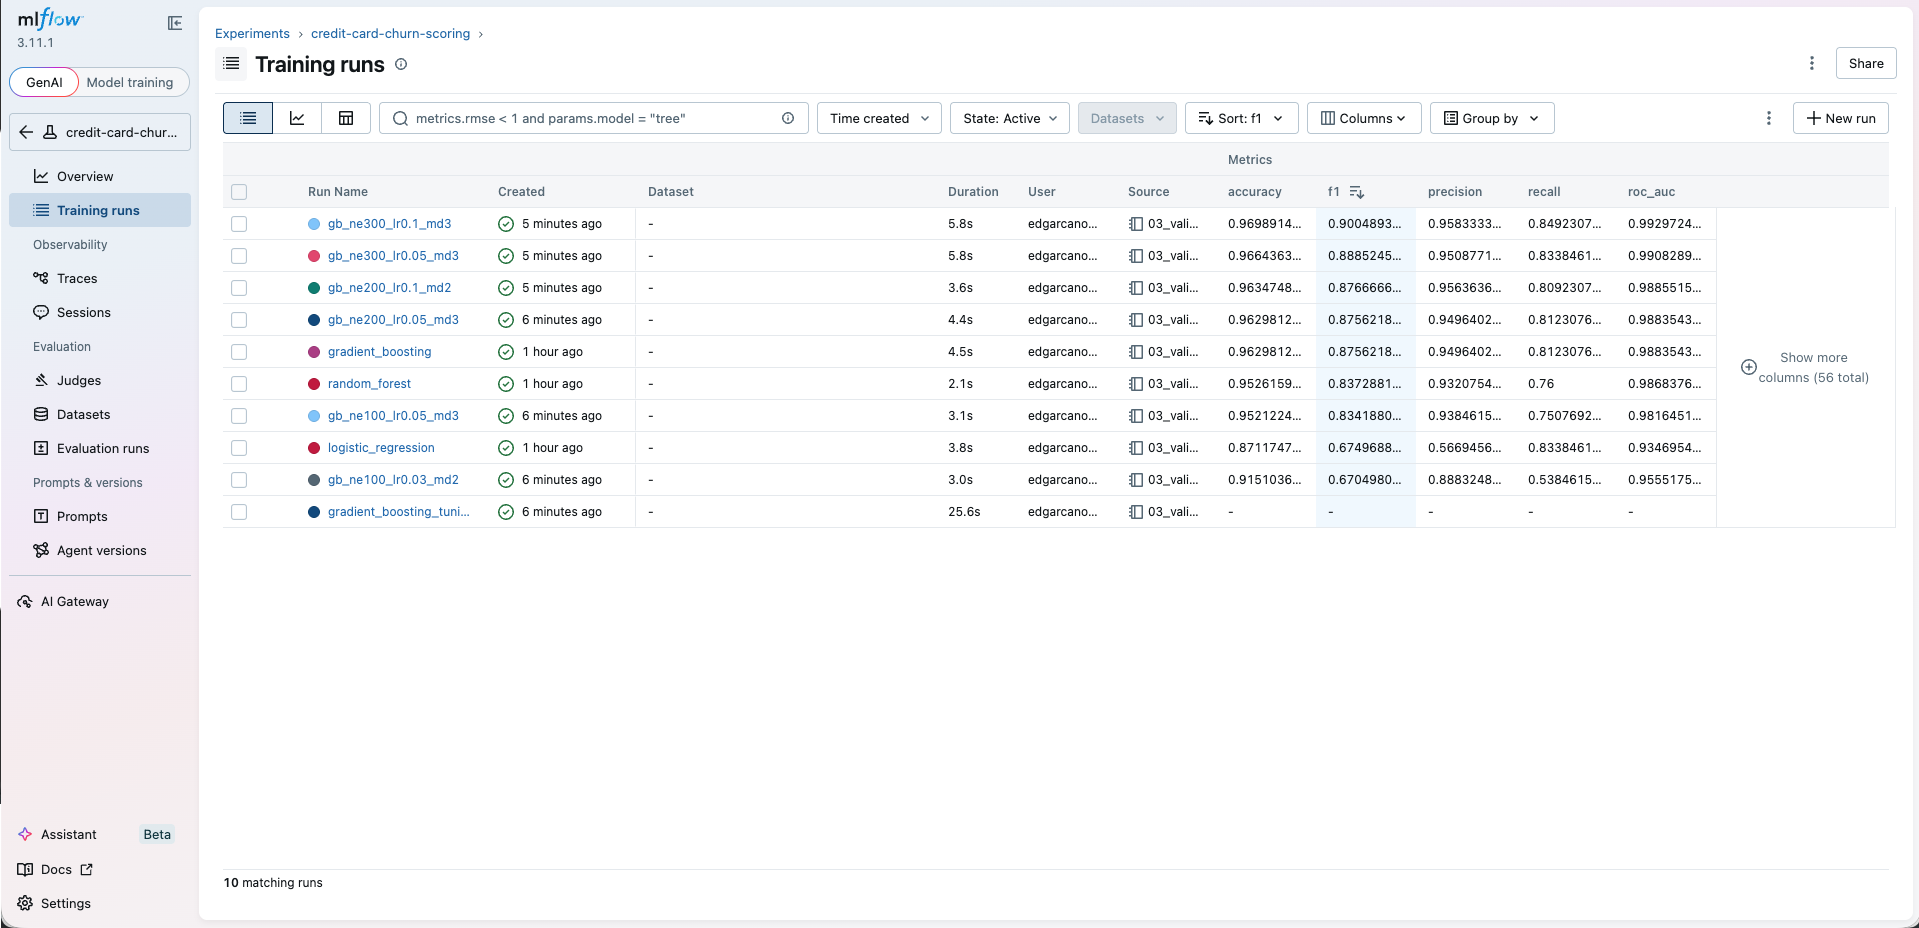

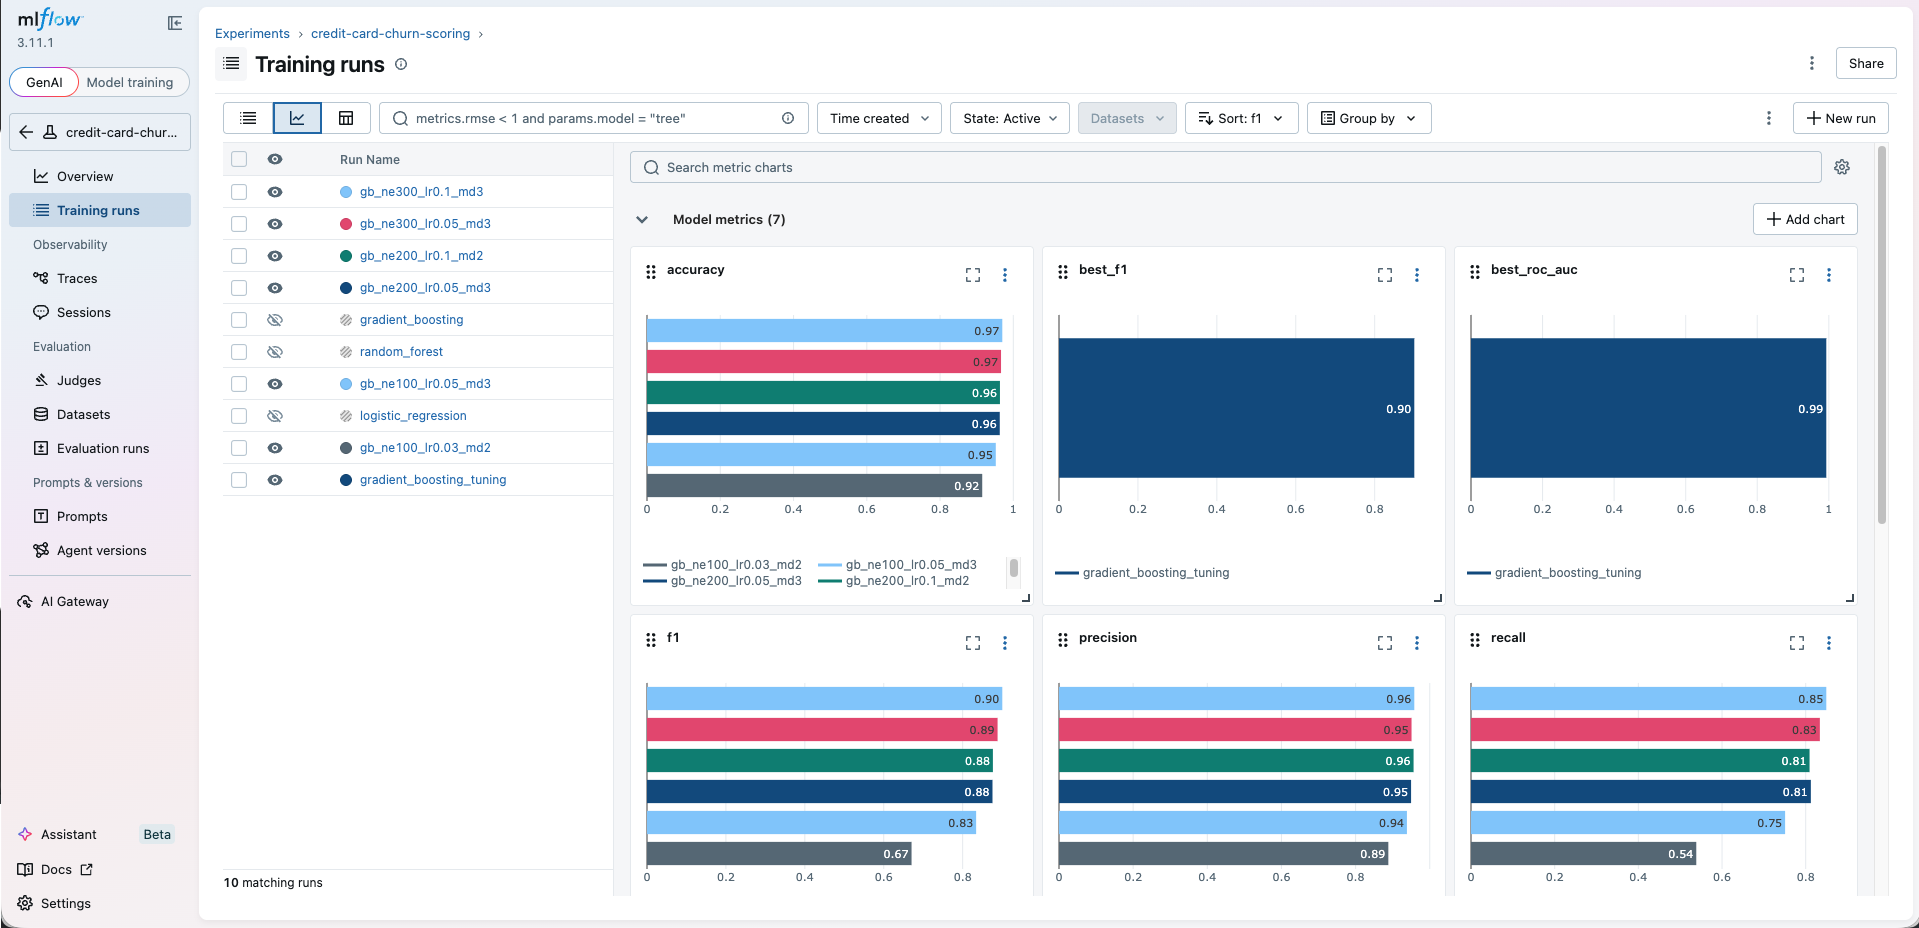

In [71]:
gb_child_runs = mlflow.search_runs(
    filter_string=f"tags.mlflow.parentRunId = '{parent_run_id}'",
    order_by=["metrics.f1 DESC"],
)

gb_child_runs[
    [
        "run_id",
        "tags.mlflow.runName",
        "params.n_estimators",
        "params.learning_rate",
        "params.max_depth",
        "metrics.f1",
        "metrics.roc_auc",
        "metrics.precision",
        "metrics.recall",
    ]
]

,run_id,tags.mlflow.runName,params.n_estimators,params.learning_rate,params.max_depth,metrics.f1,metrics.roc_auc,metrics.precision,metrics.recall
0,e650a2d695bb4b81a1931abc47d30e2e,gb_ne300_lr0.1_md3,300,0.1,3,0.900489,0.992972,0.958333,0.849231
1,1dcfb4a8ec704b5fbc13376d0f0dec44,gb_ne300_lr0.05_md3,300,0.05,3,0.888525,0.990829,0.950877,0.833846
2,16d74064bc70406a9ffd58e446f7a991,gb_ne200_lr0.1_md2,200,0.1,2,0.876667,0.988552,0.956364,0.809231
3,41e8d910828c4f42bfb81a9b6493e92f,gb_ne200_lr0.05_md3,200,0.05,3,0.875622,0.988354,0.949640,0.812308
4,3e8d05b785684fcc9801b0226e5713b0,gb_ne100_lr0.05_md3,100,0.05,3,0.834188,0.981645,0.938462,0.750769
5,7a36d2fe93e84590981cf295e158bb25,gb_ne100_lr0.03_md2,100,0.03,2,0.670498,0.955518,0.888325,0.538462


In [72]:
best_child = gb_child_runs.iloc[0]

best_child[
    [
        "run_id",
        "tags.mlflow.runName",
        "params.n_estimators",
        "params.learning_rate",
        "params.max_depth",
        "metrics.f1",
        "metrics.roc_auc",
        "metrics.precision",
        "metrics.recall",
    ]
]

run_id                  e650a2d695bb4b81a1931abc47d30e2e
tags.mlflow.runName                   gb_ne300_lr0.1_md3
params.n_estimators                                  300
params.learning_rate                                 0.1
params.max_depth                                       3
metrics.f1                                      0.900489
metrics.roc_auc                                 0.992972
metrics.precision                               0.958333
metrics.recall                                  0.849231
Name: 0, dtype: object

### Resultados del tuning con parent-child runs en MLflow

La estructura de **parent run + child runs** permitió organizar de forma clara el proceso de ajuste de hiperparámetros sobre el modelo **Gradient Boosting**.

En la interfaz de MLflow se observan:

- 3 corridas baseline correspondientes a los modelos iniciales;
- 1 parent run que agrupa el experimento general de tuning;
- 6 child runs, cada uno asociado a una combinación específica de hiperparámetros.

Al ordenar los resultados por **F1-score**, la mejor configuración encontrada fue:

- `n_estimators = 300`
- `learning_rate = 0.1`
- `max_depth = 3`

Esta variante superó al modelo base de Gradient Boosting, lo que indica que el ajuste de hiperparámetros permitió mejorar el desempeño del modelo dentro de la misma familia.

## 8. Registro de artifacts del mejor modelo

Una vez identificada la mejor configuración de **Gradient Boosting** durante el proceso de tuning, se reentrena dicha variante como modelo final candidato y se registran artifacts adicionales en MLflow.

El objetivo de esta sección es complementar las métricas numéricas con evidencia visual y documental del desempeño del modelo. En particular, se registrarán:

- matriz de confusión;
- curva ROC;
- classification report;
- importancia de variables.

De esta manera, el experimento no solo conserva hiperparámetros y métricas, sino también artefactos útiles para análisis, comunicación y toma de decisiones.

In [73]:
best_child = tuning_results_df.iloc[0]

best_config = {
    "n_estimators": int(best_child["n_estimators"]),
    "learning_rate": float(best_child["learning_rate"]),
    "max_depth": int(best_child["max_depth"]),
}

best_config

{'n_estimators': 300, 'learning_rate': 0.1, 'max_depth': 3}

In [78]:
def log_best_model_with_artifacts(best_config, x_train, x_test, y_train, y_test):
    run_name = "gradient_boosting_best_candidate"

    with mlflow.start_run(run_name=run_name):
        model = GradientBoostingClassifier(
            n_estimators=best_config["n_estimators"],
            learning_rate=best_config["learning_rate"],
            max_depth=best_config["max_depth"],
            random_state=42,
        )

        mlflow.log_params(
            {
                "model_name": "gradient_boosting",
                "n_estimators": best_config["n_estimators"],
                "learning_rate": best_config["learning_rate"],
                "max_depth": best_config["max_depth"],
            }
        )

        mlflow.set_tags(
            {
                "author": "Edd",
                "dataset_version": "churn_validated.parquet",
                "purpose": "best_model_with_artifacts",
                "model_family": "gradient_boosting",
            }
        )

        pipe, metrics = train_and_evaluate(
            model=model,
            X_train=X_train,
            X_test=X_test,
            y_train=y_train,
            y_test=y_test,
        )

        mlflow.log_metrics(metrics)
        mlflow.sklearn.log_model(pipe, name="model")

        y_pred = pipe.predict(X_test)
        y_proba = pipe.predict_proba(X_test)[:, 1]

        with tempfile.TemporaryDirectory() as tmpdir:
            tmpdir = Path(tmpdir)

            # 1. Confusion matrix
            fig, ax = plt.subplots(figsize=(6, 5))
            ConfusionMatrixDisplay.from_predictions(
                y_test,
                y_pred,
                ax=ax,
            )
            ax.set_title("Confusion Matrix - Best Gradient Boosting")
            fig.tight_layout()
            cm_path = tmpdir / "confusion_matrix.png"
            fig.savefig(cm_path, dpi=150)
            plt.close(fig)

            # 2. ROC curve
            fpr, tpr, _ = roc_curve(y_test, y_proba)
            roc_auc_value = auc(fpr, tpr)

            fig, ax = plt.subplots(figsize=(6, 5))
            ax.plot(fpr, tpr, label=f"AUC = {roc_auc_value:.4f}")
            ax.plot([0, 1], [0, 1], linestyle="--")
            ax.set_xlabel("False Positive Rate")
            ax.set_ylabel("True Positive Rate")
            ax.set_title("ROC Curve - Best Gradient Boosting")
            ax.legend()
            fig.tight_layout()
            roc_path = tmpdir / "roc_curve.png"
            fig.savefig(roc_path, dpi=150)
            plt.close(fig)

            # 3. Classification report
            report = classification_report(y_test, y_pred, output_dict=True)
            report_path = tmpdir / "classification_report.json"
            with open(report_path, "w", encoding="utf-8") as f:
                json.dump(report, f, indent=2)

            # 4. Feature importance
            preprocessor = pipe.named_steps["preprocessor"]
            classifier = pipe.named_steps["classifier"]

            feature_names = preprocessor.get_feature_names_out()
            importances = classifier.feature_importances_

            feature_importance_df = (
                pd.DataFrame(
                    {
                        "feature": feature_names,
                        "importance": importances,
                    }
                )
                .sort_values("importance", ascending=False)
                .reset_index(drop=True)
            )

            fi_csv_path = tmpdir / "feature_importance.csv"
            feature_importance_df.to_csv(fi_csv_path, index=False)

            top_features = feature_importance_df.head(15)

            fig, ax = plt.subplots(figsize=(10, 6))
            ax.barh(top_features["feature"][::-1], top_features["importance"][::-1])
            ax.set_title("Top 15 Feature Importances - Best Gradient Boosting")
            ax.set_xlabel("Importance")
            fig.tight_layout()
            fi_plot_path = tmpdir / "feature_importance.png"
            fig.savefig(fi_plot_path, dpi=150)
            plt.close(fig)

            # Log artifacts
            mlflow.log_artifact(cm_path)
            mlflow.log_artifact(roc_path)
            mlflow.log_artifact(report_path)
            mlflow.log_artifact(fi_csv_path)
            mlflow.log_artifact(fi_plot_path)

        return pipe, metrics, feature_importance_df

In [81]:
best_pipe, best_metrics, feature_importance_df = log_best_model_with_artifacts(
    best_config=best_config,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
)

best_metrics

2026/04/22 17:53:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


{'accuracy': 0.9698914116485686,
 'precision': 0.9583333333333334,
 'recall': 0.8492307692307692,
 'f1': 0.9004893964110929,
 'roc_auc': 0.9929724596391263}

In [82]:
feature_importance_df.head(15)

,feature,importance
0,num__Total_Trans_Ct,0.317185
1,num__Total_Revolving_Bal,0.185582
2,num__Total_Trans_Amt,0.168859
3,num__Total_Ct_Chng_Q4_Q1,0.094939
4,num__Total_Relationship_Count,0.086534
5,num__Avg_Trans_Amt,0.039415
6,num__Total_Amt_Chng_Q4_Q1,0.037564
7,num__Contacts_Count_12_mon,0.016101
8,num__Months_Inactive_12_mon,0.014003
9,num__Customer_Age,0.012619


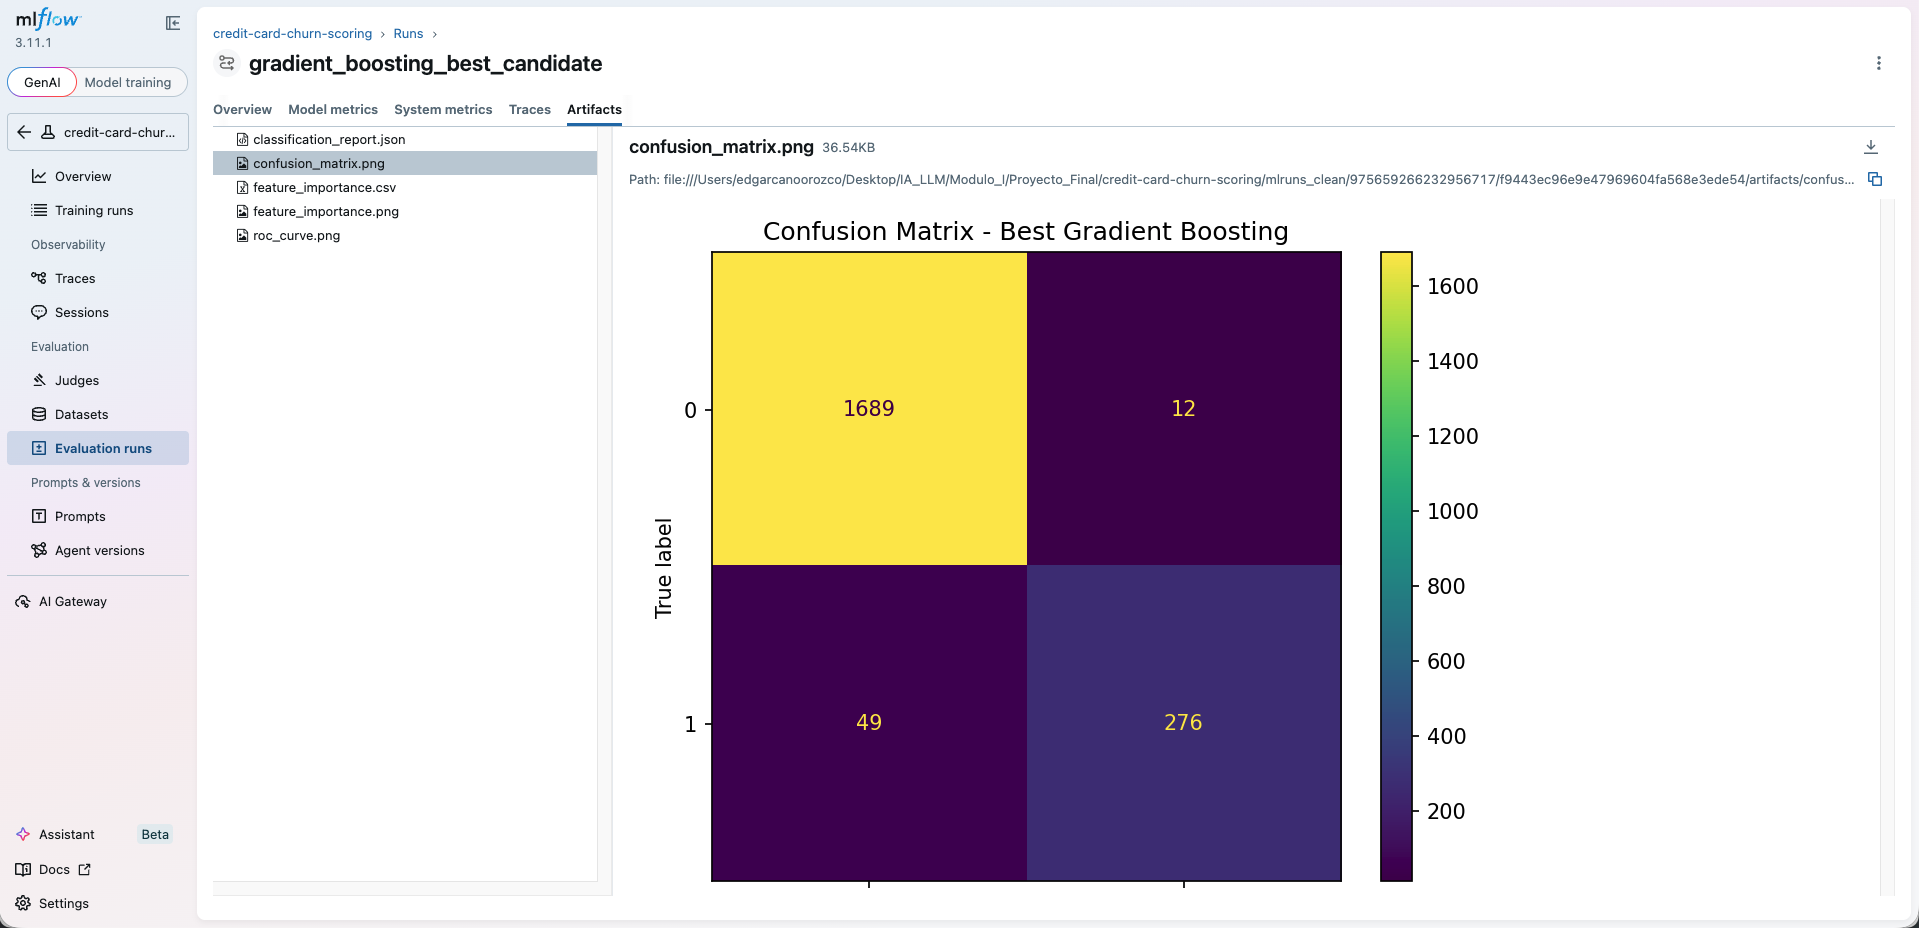

### Interpretación

Además de registrar métricas y el modelo serializado, el mejor modelo se complementó con artifacts que permiten interpretar y comunicar mejor su desempeño.

La matriz de confusión permite observar el balance entre aciertos y errores de clasificación; la curva ROC resume la capacidad discriminatoria del modelo; el classification report documenta precisión, recall y F1 de manera estructurada; y la importancia de variables ofrece una primera aproximación a las features con mayor influencia en la predicción.

Con ello, el experimento final queda mejor documentado dentro de MLflow y más alineado con un flujo profesional de evaluación de modelos.

### Conclusión final

El mejor modelo obtenido en esta etapa fue **Gradient Boosting** ajustado con:

- `n_estimators = 300`
- `learning_rate = 0.10`
- `max_depth = 3`

Esta configuración superó al modelo base y logró el mejor balance entre precisión y recall, reflejado en el mayor **F1-score** entre las alternativas evaluadas.  
Además, su **ROC-AUC** cercano a 0.993 confirma una muy buena capacidad discriminatoria.

Por ello, esta variante se considera el **modelo final candidato** dentro del flujo de scikit-learn y será la referencia principal para las siguientes etapas del proyecto.